**Load Data**

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/diaz3z/logistic-regression-dataset/User_Data.csv")

print(df.head())
print(df.columns)

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


**Extract Fields**

In [83]:
X = df[["Age", "EstimatedSalary"]].to_numpy(dtype=np.float64)
y = df["Purchased"].to_numpy(dtype=np.float64)

**Split Data into test/train**

In [84]:
rng = np.random.default_rng(42)

indices = np.arange(len(X))
rng.shuffle(indices)

test_size = int(0.2 * len(X))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]
mean = X_train.mean(axis=0) 
std = X_train.std(axis=0)
if np.any(std == 0): 
	raise ValueError("At least one feature has zero variance.") 
X_train = (X_train - mean) / std 
X_test = (X_test - mean) / std

**Visualisation with scatter plot**

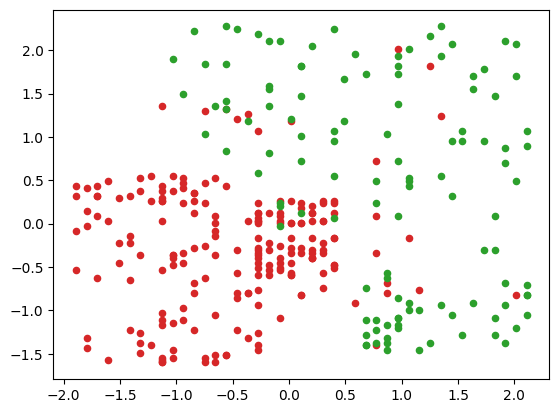

In [85]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:red',label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:green',label='Class 1', s=20)

While there is some overlapping, a relatively clear decsion boundary exist.

In [86]:
def sigmoid(z):
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    else:
        exp_z = np.exp(z)
        return exp_z / (1 + exp_z)

In [87]:
def cost_func(X, y, w, b):
    m = X.shape[0]
    cost_sum = 0.0
    epsilon = 1e-15

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        g = np.clip(g, epsilon, 1 - epsilon)

        cost_sum += (
            -y[i] * np.log(g)
            -(1 - y[i]) * np.log(1 - g)
        )

    return cost_sum / m

In [88]:
def gradient_func(X, y, w, b):
    m, n = X.shape

    grad_w = np.zeros(n)
    grad_b = 0.0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        error = g - y[i]

        grad_b += error

        for j in range(n):
            grad_w[j] += error * X[i, j]

    grad_w /= m
    grad_b /= m

    return grad_b, grad_w

In [89]:
def grad_des(X, y, alpha, iterations):
    _, n = X.shape

    w = np.zeros(n)
    b = 0.0

    for i in range(iterations):
        grad_b, grad_w = gradient_func(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        if i % 1000 == 0:
            print(f"{i}: {cost_func(X, y, w, b)}")

    return w, b

In [90]:
def predict(X, w, b):
    m = X.shape[0]
    predictions = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        predictions[i] = 1 if g >= 0.5 else 0

    return predictions

In [91]:
learning_rate = 0.001
iterations = 10000

final_w, final_b = grad_des(
    X_train,
    y_train,
    learning_rate,
    iterations
)

predictions_train = predict(X_train, final_w, final_b)
predictions_test = predict(X_test, final_w, final_b)

print("Prediction shapes:")
print(predictions_train.shape, y_train.shape)
print(predictions_test.shape, y_test.shape)

accuracy_train = np.mean(predictions_train == y_train) * 100
accuracy_test = np.mean(predictions_test == y_test) * 100

print(f"Training accuracy: {accuracy_train:.2f}")
print(f"Test accuracy: {accuracy_test:.2f}")


0: 0.6930064045684983
1000: 0.5842060491175834
2000: 0.5187862453043391
3000: 0.4768952857500975
4000: 0.4483736517005485
5000: 0.4279454400422697
6000: 0.41271301995320886
7000: 0.40098585558337385
8000: 0.39172240701182426
9000: 0.3842502490662385
Prediction shapes:
(320,) (320,)
(80,) (80,)
Training accuracy: 84.38
Test accuracy: 82.50
